# Tutorial: Animated movie of activity over time

To create an animation of activity over time you need to have:
- the Gifti image of the surface you want to plot on: this will be your base mesh on which you will overlay colors
- list of scalars/ colors that respresents the layer time series. shape: N frames x N colored vertices

*ATTENTION: To animate and see the layered activity over time you need a new environment with newer version of matplotlib than in the lameg environment*

In [3]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import pyvista as pv
import imageio
from scipy.spatial import cKDTree, KDTree

def _find_project_root(marker: str = "utils") -> Path:
    for parent in Path(__file__).resolve().parents:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Project root with marker '{marker}' not found.")
 
sys.path.insert(0, str(_find_project_root()))

from utils.config_loader import load_config
from utils.utils import find_clusters, sort_clusters_by_metrics

In [4]:
#load your surface
surf_path = '/home/sgailhard/Documents/laminar_meg/data/cued_action_meg/fs/'
subject_id = 'sub-001'
subj_surf_path = os.path.join(surf_path, subject_id, 'surf', 'laminar')
surf_fname = os.path.join(subj_surf_path, f'inflated.ds.gii')

mesh = nib.load(surf_fname)

In [5]:
# this is to get the clusters of vertices to plot at each time point on the inflated surface
ds_fname = os.path.join(subj_surf_path, f'multilayer.11.ds.link_vector.fixed.gii')
ds_mesh = nib.load(ds_fname)
ds_mesh.darrays[1].data.shape
faces_ds = ds_mesh.darrays[1].data

n_layers = 11
vertices_ds = ds_mesh.darrays[0].data.shape[0]
verts_per_surf = vertices_ds // n_layers

In [6]:
output_dir = '../output/empirical/'
layer_ts_fname = 'layer_ts_mean_-500_500_sliding_win25_n11_p5_o0_5.npy' 
#layer_ts_fname = 'layer_ts_mean_fullepoch_nosliding_n11_p5.npy'
time_fname = "time_full.npy"
layer_ts_path = os.path.join(output_dir, layer_ts_fname)
time_path = os.path.join(output_dir, time_fname)

# load the layer_ts and time arrays
layer_ts_full = np.load(layer_ts_path)
time_full = np.load(time_path)

In [7]:
# find the epoch size of reconstruction
epoch_size = [np.where(time_full >= -500)[0][0], np.where(time_full <= 500)[0][-1]] #based on layer_ts_fname

# get the appropriate length of layer_ts for the epoch
layer_ts = layer_ts_full[:,epoch_size[0]:epoch_size[1]]
time = time_full[epoch_size[0]:epoch_size[1]]

In [8]:
from matplotlib import cm, colors
# two functions from lameg_viz to convert data to rgb colors for plotting on the surface
def data_to_rgb(data, n_bins, cmap, vmin, vmax, vcenter=0.0, ret_map=False, norm="TS"):
   
    if norm == "TS":
        divnorm = colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    elif norm == "N":
        divnorm = colors.Normalize(vmin=vmin, vmax=vmax)
    elif norm == "LOG":
        divnorm = colors.LogNorm(vmin=vmin, vmax=vmax, clip=True)
    else:
        raise ValueError("norm must be TS, N, or LOG")

    scalar_map = cm.ScalarMappable(divnorm, cmap=cmap)
    bins = np.histogram_bin_edges(data, bins=n_bins)
    bin_ranges = list(zip(bins[:-1], bins[1:]))
    color_mapped = np.zeros((data.shape[0], 4))
    for br_ix, bin_range in enumerate(bin_ranges):
        map_c = (data >= bin_range[0]) & (data <= bin_range[1])
        color_mapped[map_c, :] = scalar_map.to_rgba(bins[1:][br_ix])

    if not ret_map:
        return color_mapped
    return color_mapped, scalar_map

def color_map(data, cmap, vmin, vmax, n_bins=1000, vcenter=0, norm="TS"):
    map_colors, c_map = data_to_rgb(
        data, n_bins, cmap, vmin, vmax,
        vcenter=vcenter, ret_map=True, norm=norm
    )
    map_colors = map_colors[:, :3] * 255
    map_colors = map_colors.astype(int)
    return map_colors, c_map

In [9]:
# compute the color range from the whole data
c_range = [np.percentile(layer_ts,1), np.percentile(layer_ts,99.9)]

In [10]:
# store results for each time point and visualization
res = {
    'clust_sorted_combined': [],    
    'clust_metrics_comb': [],
    'vmin_vmax': [],
    'colors': []
}   

for t in range(layer_ts.shape[1]):
    layer_ts_mean = np.abs(np.mean(layer_ts[:,t:t+1], axis=1))
    threshold = np.percentile(layer_ts_mean, 99.9)
    high_activity_mask = layer_ts_mean > threshold
    source_idx = np.where(high_activity_mask)[0]
    values = layer_ts_mean[source_idx]
    sorted_indices = np.argsort(values)[::-1]
    top_sources = source_idx[sorted_indices]
    top_values = values[sorted_indices]
    
    _, unique_indices = np.unique(top_sources, return_index=True)
    unique_first_idx = np.sort(unique_indices)
    unique_ordered_sources = top_sources[unique_first_idx]
    pial_ordered_verts = unique_ordered_sources % verts_per_surf
    seen = set()
    unique_pial_mask = []
    for i, v in enumerate(pial_ordered_verts):
        if v not in seen:
            unique_pial_mask.append(i)
            seen.add(v)
    unique_pial_ordered_verts = pial_ordered_verts[unique_pial_mask]
    #print(f"Time {time[t]:.1f} ms: {len(unique_pial_ordered_verts)} unique pial vertices")
    
    # find clusters
    s_clusters = find_clusters(faces_ds, unique_pial_ordered_verts, n_hops=1)
    
    # filter by combinaison
    try:
        sorted_combined, _, metrics_comb = sort_clusters_by_metrics(
            s_clusters, layer_ts_mean, 
            sort_by='combined',
            weight_size=0.5,
            weight_mean=0.5
        )
    except ValueError as e:
        print(f"Time {time[t]:.1f} ms: skipping — {e}")
        res['clust_sorted_combined'].append([])
        res['clust_metrics_comb'].append([])
        res['vmin_vmax'].append(c_range)
        res['colors'].append(None)
        continue

    rgb_colors, _ = color_map(
        layer_ts_mean[0:verts_per_surf],
        "Spectral_r",
        c_range[0],
        c_range[1],
        norm='N'
    )
    res['clust_sorted_combined'].append(sorted_combined)
    res['clust_metrics_comb'].append(metrics_comb)
    res['vmin_vmax'].append(c_range)
    res['colors'].append(rgb_colors)

In [11]:
len(res['clust_sorted_combined'])

600

In [12]:
# Assume `gifti_mesh` is your nibabel GiftiImage
vertices, faces = mesh.agg_data()  # or gifti_mesh.darrays
faces = np.hstack([[3, *f] for f in faces])  # convert to PyVista face format

# Create PyVista mesh
pv_mesh = pv.PolyData(vertices, faces)

In [13]:
pv_mesh

PolyData,Information
N Cells,63377
N Points,32028
N Strips,0
X Bounds,"-2.959e+01, 1.824e+02"
Y Bounds,"-9.263e+01, 1.811e+02"
Z Bounds,"-1.339e+02, 7.383e+01"
N Arrays,0


In [14]:
pv.set_jupyter_backend('static')

In [61]:
#filename = 'animation.gif' 
filename = 'animation.mp4'
plotter = pv.Plotter()
plotter.open_movie(filename)
#plotter.open_gif(filename)

2026-02-17 16:26:53.127 (1845.827s) [    7F7367CEE240] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x25b84f50): EGL device index: 0 could not be initialized. Trying other devices...
2026-02-17 16:26:53.153 (1845.853s) [    7F7367CEE240] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x25b84f50): EGL device index: 0 could not be initialized. Trying other devices...


ValueError: Could not find a backend to open `animation.mp4`` with iomode `w?`.
Based on the extension, the following plugins might add capable backends:
  FFMPEG:  pip install imageio[ffmpeg]
  pyav:  pip install imageio[pyav]

In [55]:
plotter.camera_position = 'yz'
plotter.camera.azimuth = 180     # +90 au lieu de -90 (opposé)
plotter.camera.elevation = 20
plotter.camera.roll += 20
plotter.reset_camera_clipping_range()

In [53]:
vertex_colors = np.array(res['colors'][0], dtype=float) / 255.0
pv_mesh.point_data['colors'] = vertex_colors
plotter.add_mesh(pv_mesh, scalars="colors", rgb=True)

Actor (0x7f70e3438e80)
  Center:                     (76.40035343170166, 44.223350524902344, -30.03894805908203)
  Pickable:                   True
  Position:                   (0.0, 0.0, 0.0)
  Scale:                      (1.0, 1.0, 1.0)
  Visible:                    True
  X Bounds                    -2.959E+01, 1.824E+02
  Y Bounds                    -9.263E+01, 1.811E+02
  Z Bounds                    -1.339E+02, 7.383E+01
  User matrix:                Identity
  Has mapper:                 True

Property (0x7f70d687d360)
  Ambient:                     0.0
  Ambient color:               Color(name='lightblue', hex='#add8e6ff', opacity=255)
  Anisotropy:                  0.0
  Color:                       Color(name='lightblue', hex='#add8e6ff', opacity=255)
  Culling:                     "none"
  Diffuse:                     1.0
  Diffuse color:               Color(name='lightblue', hex='#add8e6ff', opacity=255)
  Edge color:                  Color(name='black', hex='#000000ff', op

In [ ]:
text_actor = plotter.add_text("", position='upper_left', font_size=12, color='white', name='time_text')

for i, frame_colors in enumerate(res['colors']):
    # Update mesh colors
    vertex_colors = np.array(frame_colors, dtype=float) / 255.0
    pv_mesh.point_data["colors"][:] = vertex_colors #directly modify in place the mesh scalars
    #plotter.update_scalars(vertex_colors, mesh=pv_mesh, render=False)

    # Update texte avec le temps
    plotter.add_text(f"t = {time[i]:.1f} ms  (frame {i})", 
                     position='upper_left', 
                     font_size=12, 
                     color='black', 
                     name='time_text')  # même name = remplace le précédent
    
    # Update cluster points
    plotter.remove_actor("cluster_points")
    if res['clust_sorted_combined'][i] is not None:
        first_cluster = res['clust_sorted_combined'][i][0]
        cluster_coords = pv_mesh.points[first_cluster]
        cluster_points = pv.PolyData(cluster_coords)
        plotter.add_points(cluster_points, color='blue', point_size=10, name="cluster_points")
    
    plotter.write_frame()

/home/sgailhard/miniconda3/envs/viz_lameg/lib/python3.13/site-packages/pyvista/plotting/plotter.py:4989: PyVistaDeprecationWarning: This method is deprecated and will be removed in a future version of PyVista. Directly modify the scalars of a mesh in-place instead.
  warnings.warn(


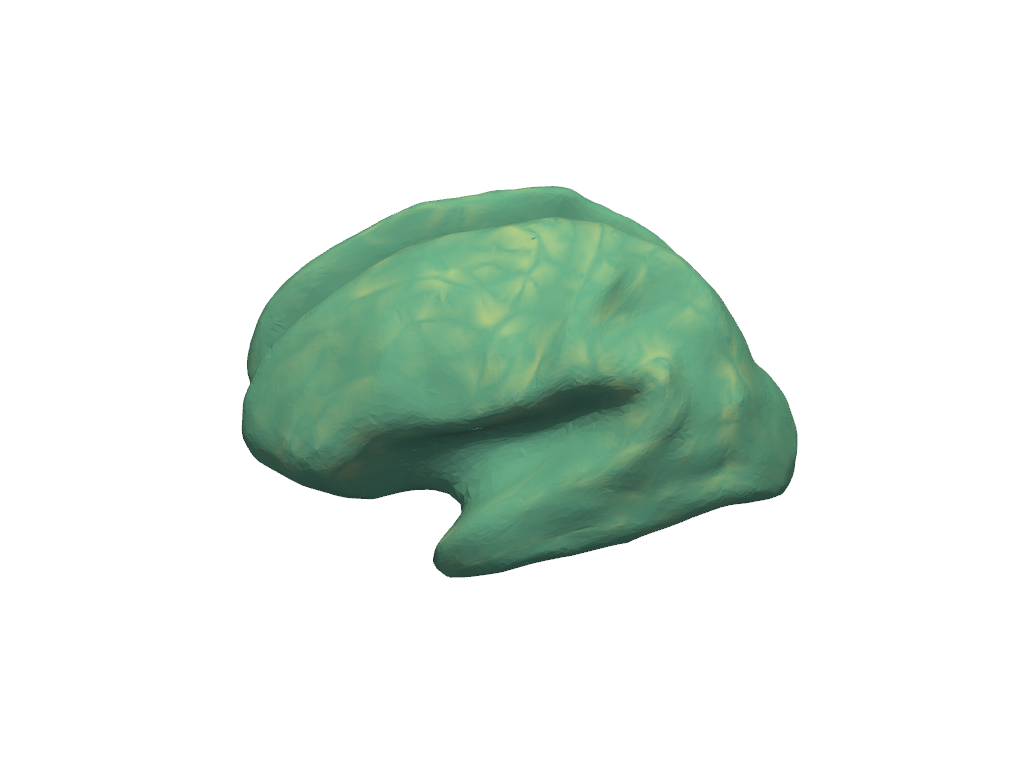

In [57]:
plotter.show()

In [59]:
plotter.close()

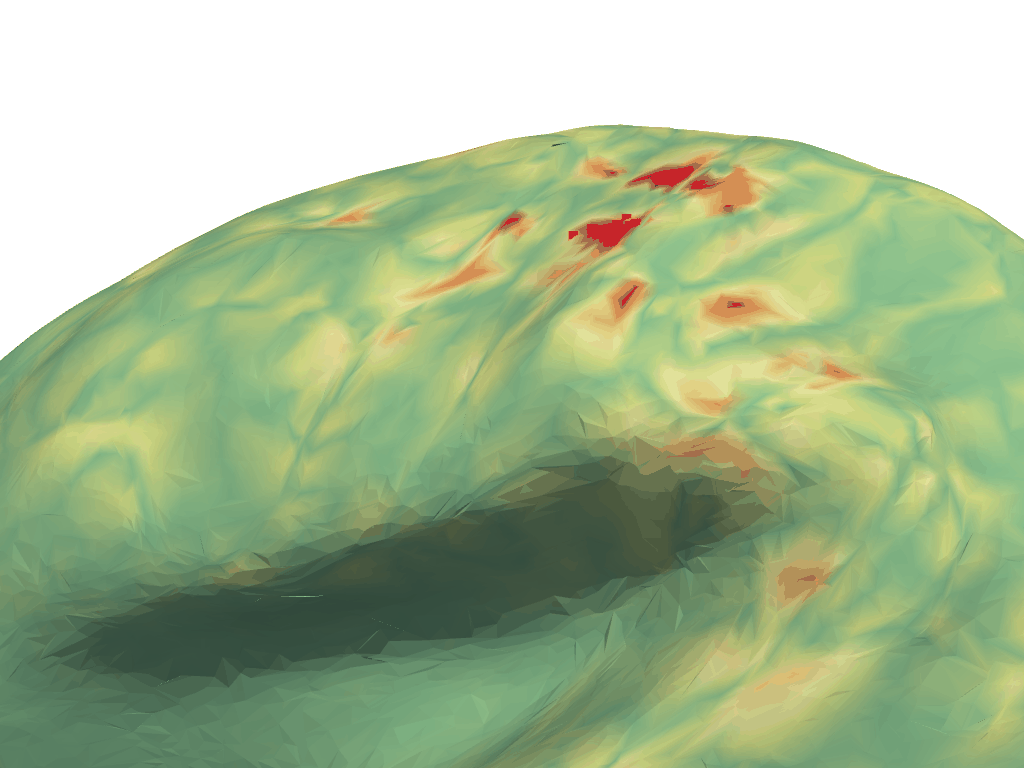

In [38]:
# to display the animation in the notebook
from IPython.display import Image
Image("animation.gif")